In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('/content/dataset_alterprompt.csv')

In [16]:
df.head()

,question_id,discipline,question_type,difficulty_level,question_text,option_A,option_B,option_C,option_D,correct_answer,GPT Response,Gemini Response,Grok Response
0,CS_MCQ_01,Computer Science,MCQ,Easy,Which of the following best describes data str...,Stack,Queue,Heap,Linked List,C,C,C,C
1,CS_MCQ_02,Computer Science,MCQ,Easy,Choose the correct description of is the worst...,O(1),O(log n),O(n),O(n log n),B,B,B,B
2,CS_MCQ_03,Computer Science,MCQ,Easy,What is the correct explanation for protocol i...,FTP,SMTP,HTTPS,SNMP,C,C,C,C
3,CS_MCQ_04,Computer Science,MCQ,Easy,Choose the correct description of does CPU sta...,Central Processing Unit,Computer Processing Unit,Central Program Unit,Control Processing Unit,A,A,A,A
4,CS_MCQ_05,Computer Science,MCQ,Easy,What is the correct explanation for component ...,RAM,CPU,ROM,Cache,C,C,C,C


         Correct Answers
ChatGPT              172
Gemini               168
Groq                 168


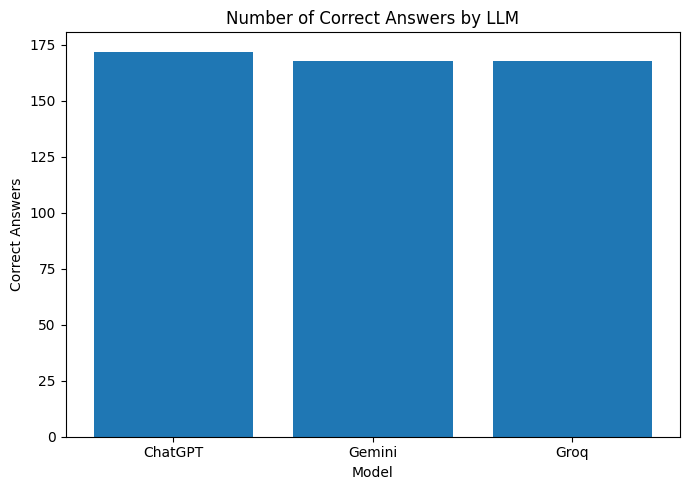

In [17]:
models = {
    "ChatGPT": "GPT Response",
    "Gemini": "Gemini Response",
    "Groq": "Grok Response"
}

correct_counts = {}
for model_name, col in models.items():
    correct_counts[model_name] = (df[col] == df["correct_answer"]).sum()

# Convert to DataFrame
results_df = pd.DataFrame.from_dict(
    correct_counts, orient="index", columns=["Correct Answers"]
)

print(results_df)

# Plot comparison
plt.figure(figsize=(7, 5))
plt.bar(results_df.index, results_df["Correct Answers"])
plt.title("Number of Correct Answers by LLM")
plt.xlabel("Model")
plt.ylabel("Correct Answers")
plt.tight_layout()
plt.show()

In [18]:
accuracy_records = []

for model_name, col in models.items():
    for difficulty, group in df.groupby("difficulty_level"):
        accuracy = (group[col] == group["correct_answer"]).mean() * 100
        accuracy_records.append({
            "Model": model_name,
            "Difficulty": difficulty,
            "Accuracy (%)": accuracy
        })

accuracy_df = pd.DataFrame(accuracy_records)

print(accuracy_df)

     Model Difficulty  Accuracy (%)
0  ChatGPT       Easy    100.000000
1  ChatGPT       Hard     94.736842
2  ChatGPT     Medium    100.000000
3   Gemini       Easy    100.000000
4   Gemini       Hard     91.228070
5   Gemini     Medium     97.058824
6     Groq       Easy     96.000000
7     Groq       Hard     94.736842
8     Groq     Medium     97.058824


In [19]:
accuracy_pivot = accuracy_df.pivot(
    index="Difficulty",
    columns="Model",
    values="Accuracy (%)"
)

print(accuracy_pivot)

Model          ChatGPT      Gemini       Groq
Difficulty                                   
Easy        100.000000  100.000000  96.000000
Hard         94.736842   91.228070  94.736842
Medium      100.000000   97.058824  97.058824


In [20]:
overall_accuracy = {
    model: (df[col] == df["correct_answer"]).mean() * 100
    for model, col in models.items()
}

overall_acc_df = pd.DataFrame.from_dict(
    overall_accuracy, orient="index", columns=["Overall Accuracy (%)"]
)

print(overall_acc_df)

         Overall Accuracy (%)
ChatGPT             98.285714
Gemini              96.000000
Groq                96.000000


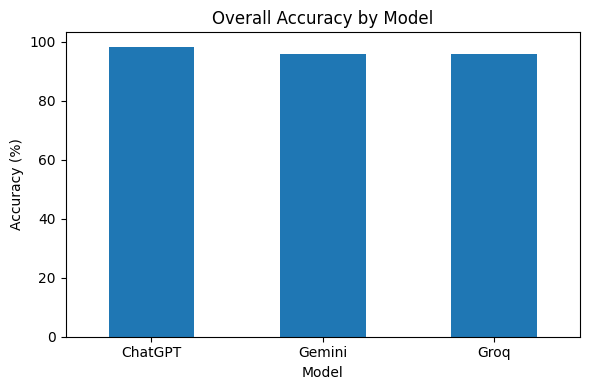

In [21]:
overall_acc_df.plot(kind="bar", legend=False, figsize=(6,4))
plt.title("Overall Accuracy by Model")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [22]:
# Dictionary to store wrong-answer counts
wrong_by_discipline = {}

for model_name, col in models.items():
    wrong = df[df[col] != df["correct_answer"]]
    wrong_by_discipline[model_name] = wrong["discipline"].value_counts()

# Convert to DataFrame
wrong_df = pd.DataFrame(wrong_by_discipline).fillna(0).astype(int)

print("Wrong Answers per Discipline:")
print(wrong_df)

Wrong Answers per Discipline:
            ChatGPT  Gemini  Groq
discipline                       
Economics         2       6     6
Psychology        1       1     1


In [23]:
results = []

for model_name, col in models.items():
    wrong = df[df[col] != df["correct_answer"]]
    grouped = wrong.groupby(["discipline", "difficulty_level"]).size().reset_index(name="wrong_count")
    grouped["model"] = model_name
    results.append(grouped)

# Combine all models
wrong_dd_df = pd.concat(results)

print(wrong_dd_df)

   discipline difficulty_level  wrong_count    model
0   Economics             Hard            2  ChatGPT
1  Psychology             Hard            1  ChatGPT
0   Economics             Hard            4   Gemini
1   Economics           Medium            2   Gemini
2  Psychology             Hard            1   Gemini
0   Economics             Easy            2     Groq
1   Economics             Hard            2     Groq
2   Economics           Medium            2     Groq
3  Psychology             Hard            1     Groq


In [24]:
pivot_df = wrong_dd_df.pivot_table(
    index=["discipline", "difficulty_level"],
    columns="model",
    values="wrong_count",
    fill_value=0
)

print(pivot_df)

model                        ChatGPT  Gemini  Groq
discipline difficulty_level                       
Economics  Easy                  0.0     0.0   2.0
           Hard                  2.0     4.0   2.0
           Medium                0.0     2.0   2.0
Psychology Hard                  1.0     1.0   1.0


In [25]:
records = []

for model_name, col in models.items():
    for (disc, diff), group in df.groupby(["discipline", "difficulty_level"]):
        total = len(group)
        wrong = (group[col] != group["correct_answer"]).sum()
        error_pct = (wrong / total) * 100 if total > 0 else 0

        records.append({
            "model": model_name,
            "discipline": disc,
            "difficulty": diff,
            "error_percentage": error_pct
        })

error_df = pd.DataFrame(records)
print(error_df.head())

     model        discipline difficulty  error_percentage
0  ChatGPT  Computer Science       Easy          0.000000
1  ChatGPT  Computer Science       Hard          0.000000
2  ChatGPT  Computer Science     Medium          0.000000
3  ChatGPT         Economics       Easy          0.000000
4  ChatGPT         Economics       Hard         13.333333


/tmp/ipython-input-3857919530.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


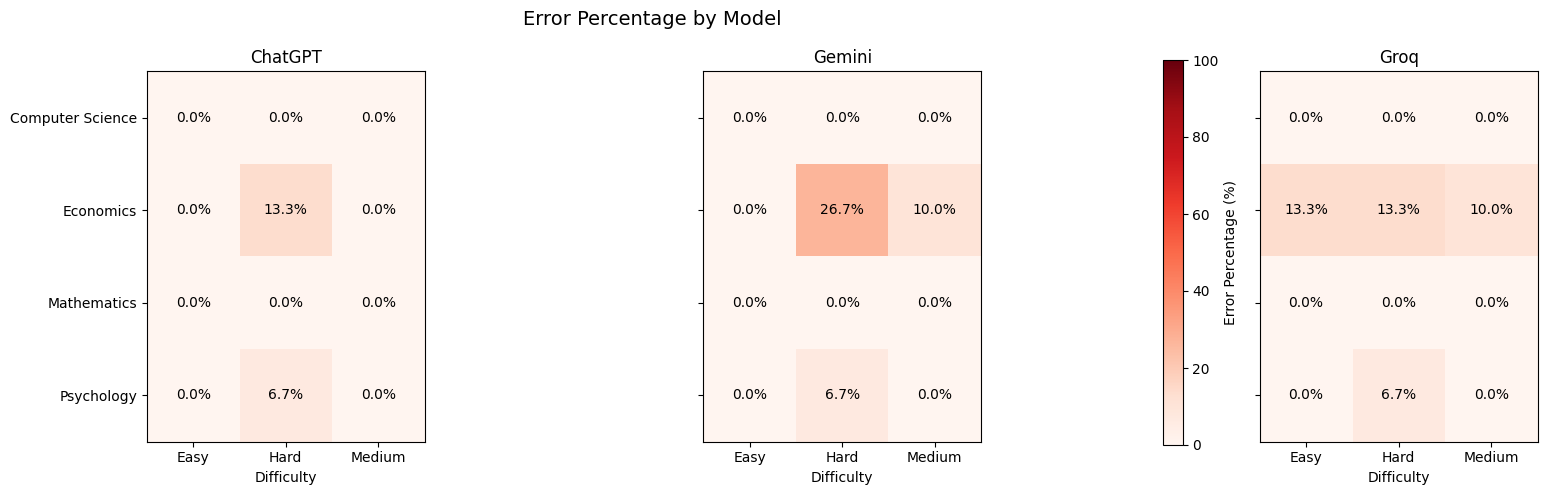

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, model in zip(axes, error_df["model"].unique()):
    pivot = error_df[error_df["model"] == model].pivot(
        index="discipline",
        columns="difficulty",
        values="error_percentage"
    )

    im = ax.imshow(pivot, cmap="Reds", vmin=0, vmax=100)

    ax.set_title(model)
    ax.set_xlabel("Difficulty")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    # Annotate values
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.iloc[i, j]:.1f}%",
                    ha="center", va="center", color="black")

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist())
cbar.set_label("Error Percentage (%)")

plt.suptitle("Error Percentage by Model", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
df["ChatGPT_correct"] = (df["GPT Response"] == df["correct_answer"]).astype(int)
df["Gemini_correct"]  = (df["Gemini Response"] == df["correct_answer"]).astype(int)
df["Groq_correct"]    = (df["Grok Response"] == df["correct_answer"]).astype(int)


In [28]:
from scipy.stats import f_oneway

chatgpt = df["ChatGPT_correct"]
gemini  = df["Gemini_correct"]
groq    = df["Groq_correct"]

f_stat, p_value = f_oneway(chatgpt, gemini, groq)

print("ANOVA across models")
print("F-statistic:", f_stat)
print("p-value:", p_value)



ANOVA across models
F-statistic: 0.9707112970711285
p-value: 0.379496226521168
